# 주별 누적 재구매확률 예측 (Discrete-Time Survival)

**입력:** `data/processed/pp_train|pp_val|pp_test.parquet` (person-period 포맷)

**모델링 구조**
- 행 단위 타깃 `y` = "해당 주차에 **최초** 재구매했는가" → 이산시간 hazard $h(t\mid x)$
- 누적 재구매확률 $F(t) = 1 - \prod_{s\le t}\bigl(1 - h(s)\bigr)$ → **단조증가 자동 보장**
- 학습/검증은 **이벤트 주차에서 절단된** 위험집합, 예측은 **4주 전체 그리드**

**평가 이원화**
| 층위 | 데이터 | 타깃 | 지표 |
|---|---|---|---|
| 주차(hazard) | 절단본 | `y` | AUC, PR-AUC, LogLoss, Brier |
| 고객(4주 누적) | 전체 그리드 | `event` | AUC, Brier, 보정곡선, 십분위 lift |

> `pp_test`는 `truncate=False`로 저장되어 있으므로 **주차 지표용 절단본을 이 노트북에서 다시 만든다.**

In [1]:
# ============================================================
# 0. 환경 설정
# ============================================================
# 필요시: pip install lightgbm
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('data/processed')
OUT_DIR  = Path('data/model');  OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

N_WEEKS = 4
SEED = 42
rng = np.random.default_rng(SEED)

print('설정 완료')

설정 완료


## 1. 적재 및 무결성 검증 / 실험용 칼럼 선택

저장 단계에서 `Customer ID`가 문자열로 변환되어 있고 `origin`은 `'YYYY-MM'` 문자열이다.
아래 검증을 **전부 통과해야** 다음 단계로 넘어간다.

In [2]:
# ============================================================
# 1. 적재
# ============================================================
def load_pp(name):
    d = pd.read_parquet(DATA_DIR / f'{name}.parquet')
    d['Customer ID'] = d['Customer ID'].astype(str)
    d['origin'] = d['origin'].astype(str)
    return d

pp_train = load_pp('pp_train')
pp_val   = load_pp('pp_val')
pp_test  = load_pp('pp_test')

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'{nm:5s} {d.shape}  origin: {sorted(d["origin"].unique())}')

print('\n칼럼:', list(pp_train.columns))

# ============================================================
# 2. 실험용 피처 선택 (파일은 23개 다 들고 있음 / 여기서 골라 씀)
# ============================================================
BASE = ['Recency', 'Frequency', 'Monetary',
        'sales_m0', 
        'sales_m1', 'sales_m2',
        'orders_m0', 'orders_m1', 'orders_m2',
        'quantity_m0', 
        'customer_tenure', 'Segment', 'week', 'pred_month']

# 실험 단계별 추가 세트
ADD_1 = ['avg_order_value', 'last_order_value', 'std_order_value']
ADD_2 = ['max_order_value', 'avg_purchase_qty', 'sales_per_tenure']
# sales_30d / 'sales_trend_1m' / 'sales_90d / 중복이라 제외
# pred_month 'cancel_m0' 'cancel_cnt' exc.
MODEL_FEATS = BASE    # ← 기준선. 1차는 BASE + ADD_1 로 바꿔가며 실험
CAT_FEATS   = ['Segment']     # CatBoost 범주형

# 파일에 실제 있는지 방어
missing = [c for c in MODEL_FEATS if c not in pp_train.columns]
assert not missing, f'파일에 없는 피처: {missing}'

train (260439, 32)  origin: ['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08']
val   (19847, 32)  origin: ['2011-09']
test  (22476, 32)  origin: ['2011-10']

칼럼: ['Customer ID', 'origin', 'split', 'Recency', 'Frequency', 'Monetary', 'sales_m0', 'sales_m1', 'sales_m2', 'orders_m0', 'orders_m1', 'orders_m2', 'quantity_m0', 'customer_tenure', 'Segment', 'week', 'pred_month', 'month', 'avg_order_value', 'sales_30d', 'sales_90d', 'last_order_value', 'max_order_value', 'std_order_value', 'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure', 'cancel_cnt', 'cancel_m0', 'y', 'event', 'week_of_repurchase']


In [3]:

# ============================================================
# 2. 무결성 검증 (실패 시 즉시 중단) 
# ============================================================
EXPECTED_SHAPE = {'train': (260439, 32), 'val': (19847, 32), 'test': (22476, 32)}

KEYS  = ['Customer ID', 'origin', 'split']
FEATS = ['Recency', 'Frequency', 'Monetary',
         'sales_m0', 'sales_m1', 'sales_m2',
         'orders_m0', 'orders_m1', 'orders_m2',
         'quantity_m0', 'customer_tenure', 'month', 'cancel_cnt','cancel_m0',
         # ── 파생 9개 전부 (파일 스키마) ──
         'avg_order_value', 'sales_30d', 'sales_90d',
         'last_order_value', 'max_order_value', 'std_order_value',
         'sales_trend_1m', 'avg_purchase_qty', 'sales_per_tenure',
         'Segment', 'week', 'pred_month']
LABEL = ['y', 'event', 'week_of_repurchase']

for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    assert d.shape == EXPECTED_SHAPE[nm], f'{nm} 형태 불일치: {d.shape}'
    assert set(KEYS + FEATS + LABEL) == set(d.columns), f'{nm} 칼럼 불일치'
    # 키 유일성: (고객, origin, 주차)
    assert not d.duplicated(['Customer ID', 'origin', 'week']).any(), f'{nm} 키 중복'
    # 주차 범위
    assert d['week'].between(1, N_WEEKS).all(), f'{nm} week 범위 이상'
    # y는 고객-origin당 최대 1회
    assert d.groupby(['Customer ID', 'origin'])['y'].sum().max() <= 1, f'{nm} y 중복 발생'
    # 라벨 정합성: y=1인 행은 반드시 event=1 이고 week == week_of_repurchase
    pos = d[d['y'] == 1]
    assert (pos['event'] == 1).all() and (pos['week'] == pos['week_of_repurchase']).all(), f'{nm} 라벨 불일치'

# 누수 컬럼 잔존 확인
LEAK = ['target_next_purchase', 'target_next_sales', 'next_month_orders',
        'last_week', 'monthly_last_purchase', 'last_purchase_date', 'month_end']
assert not (set(LEAK) & set(pp_train.columns)), '누수 컬럼 잔존'
assert not (set(LABEL) & set(FEATS)), '라벨이 피처에 포함됨'

print('무결성 검증 통과')

무결성 검증 통과


In [4]:
declared = set(KEYS + FEATS + LABEL)   # 29개
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    extra = sorted(set(d.columns) - declared)
    print(f'{nm}: {d.shape[1]}열, 여분 → {extra}')

train: 32열, 여분 → []
val: 32열, 여분 → []
test: 32열, 여분 → []


In [5]:
# ============================================================
# 3. 결측 / 분포 점검
# ============================================================
na = pd.DataFrame({
    'train': pp_train[FEATS].isna().mean(),
    'val':   pp_val[FEATS].isna().mean(),
    'test':  pp_test[FEATS].isna().mean(),
}).round(4)
print('결측률 확인(0인 행 생략)')
print(na[(na > 0).any(axis=1)])
# sales_m1/3, orders_m1/3 은 고객 초기 월에서 NaN → LightGBM이 결측 분기로 자체 처리

print('\n[주의] pred_month 분포 — split별 고유값')
for nm, d in [('train', pp_train), ('val', pp_val), ('test', pp_test)]:
    print(f'  {nm:5s}: {sorted(int(v) for v in d["pred_month"].unique())}')

print('\ntrain 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)')
print(pp_train.groupby('pred_month')['origin'].nunique().to_frame('n_origins').T)

결측률 확인(0인 행 생략)
            train     val    test
sales_m1   0.0500  0.0345  0.0390
sales_m2   0.1037  0.0537  0.0721
orders_m1  0.0500  0.0345  0.0390
orders_m2  0.1037  0.0537  0.0721

[주의] pred_month 분포 — split별 고유값
  train: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  val  : [10]
  test : [11]

train 내 pred_month별 origin 수 (test=11월의 학습 근거가 몇 개인지)
pred_month  1   2   3   4   5   6   7   8   9   10  11  12
n_origins    1   1   1   2   2   2   2   2   2   1   1   1


## 2. 절단본 생성 — 주차 지표 평가용

`pp_test`는 `truncate=False`(4주 전체)로 저장되어 있다.
2주차에 재구매한 고객의 3·4주차 행은 **위험집합에서 이미 이탈**한 관측치이므로,
그대로 두고 hazard 지표를 재면 음성 표본이 인위적으로 늘어 성능이 과대평가된다.

- **주차 hazard 평가** → 절단본 `pp_test_tr`
- **누적확률 산출** → 전체 그리드 `pp_test`

In [6]:
# ============================================================
# 4. 절단 함수
# ============================================================
# 이벤트 주차까지만 남긴다(=위험집합). 학습/검증 저장본과 동일한 규칙.
def truncate_pp(d, n_weeks=N_WEEKS):
    last_week = np.where(d['event'] == 1, d['week_of_repurchase'], n_weeks)
    return d.loc[d['week'] <= last_week].reset_index(drop=True)

# 테스트 데이터를 올바른 위험집합 형태로 절단
pp_test_tr = truncate_pp(pp_test)

# 저장본(train/val)은 이미 절단되어 있는지 역검증
assert len(truncate_pp(pp_train)) == len(pp_train), 'pp_train 절단 상태 불일치'
assert len(truncate_pp(pp_val))   == len(pp_val),   'pp_val 절단 상태 불일치'

print(f'test 전체 그리드 : {len(pp_test):,}행  (hazard {pp_test["y"].mean():.4f}  ← 편향)')
print(f'test 절단본      : {len(pp_test_tr):,}행  (hazard {pp_test_tr["y"].mean():.4f}  ← 올바름)')
print(f'제거된 사후 행   : {len(pp_test) - len(pp_test_tr):,}행')

print('\nsplit별 요약')
summary = pd.DataFrame([
    dict(split='train', rows=len(pp_train), cust=pp_train['Customer ID'].nunique(),
         hazard=pp_train['y'].mean()),
    dict(split='val',   rows=len(pp_val),   cust=pp_val['Customer ID'].nunique(),
         hazard=pp_val['y'].mean()),
    dict(split='test',  rows=len(pp_test_tr), cust=pp_test_tr['Customer ID'].nunique(),
         hazard=pp_test_tr['y'].mean()),
]).round(4)
print(summary)

test 전체 그리드 : 22,476행  (hazard 0.0618  ← 편향)
test 절단본      : 20,112행  (hazard 0.0691  ← 올바름)
제거된 사후 행   : 2,364행

split별 요약
   split    rows  cust  hazard
0  train  260439  5218  0.0551
1    val   19847  5401  0.0530
2   test   20112  5619  0.0691


In [7]:
# ============================================================
# 5. 고객 단위 정답 (4주 내 재구매 여부)
# ============================================================
def customer_truth(d):
    return (d.groupby(['Customer ID', 'origin'], as_index=False)
              .agg(event=('event', 'max'),
                   week_of_repurchase=('week_of_repurchase', 'max')))

truth_test = customer_truth(pp_test)
truth_val  = customer_truth(pp_val)#데이터프레임 변수에 저장

print(f'test 고객수 {len(truth_test):,}  |  4주 내 재구매율 {truth_test["event"].mean():.4f}')
print(f'val  고객수 {len(truth_val):,}  |  4주 내 재구매율 {truth_val["event"].mean():.4f}')

print('\ntest 최초 재구매 주차 분포')
print(truth_test.loc[truth_test['event'] == 1, 'week_of_repurchase']
      .value_counts().sort_index().to_frame('n'))

test 고객수 5,619  |  4주 내 재구매율 0.2474
val  고객수 5,401  |  4주 내 재구매율 0.1948

test 최초 재구매 주차 분포
                      n
week_of_repurchase     
1.0                 400
2.0                 401
3.0                 362
4.0                 227


## 3. 피처 준비(모델에 넣을 입력 데이터(X)와 정답(y)을 만드는 전처리 코드)

- `Segment`, `week`, `pred_month`는 범주형으로 취급 (`week`는 주차별 기저 hazard, `Segment`는 RFM 군집)
- 범주 목록은 **train 기준**으로 고정해 split 간 인코딩 어긋남을 막는다
- 불균형 보정(`is_unbalance`, `scale_pos_weight`, 오버샘플링)은 **쓰지 않는다** — 누적확률의 절대 수준이 곧 산출물이라 보정을 깨면 안 된다

In [8]:
# ============================================================
# 6. 피처 행렬
# ============================================================
CAT = [c for c in ['Segment', 'week', 'pred_month'] if c in MODEL_FEATS]   # ← MODEL_FEATS 기준
NUM = [c for c in MODEL_FEATS if c not in CAT]                             # ← FEATS → MODEL_FEATS

CAT_LEVELS = {c: sorted(pd.unique(pp_train[c].dropna())) for c in CAT}
for c, lv in CAT_LEVELS.items():
    print(f'{c:12s} ({len(lv)}): {[v.item() if hasattr(v, "item") else v for v in lv]}')

def make_X(d, feats=MODEL_FEATS):      # ← FEATS → MODEL_FEATS (핵심)
    X = d[feats].copy()
    for c in CAT:
        if c in X.columns:
            X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    for c in [x for x in feats if x not in CAT]:
        X[c] = X[c].astype('float32')
    return X

# cell 11, make_X 정의 직후 / X_tr 만들기 직전에 삽입
KEY = ['origin', 'Customer ID', 'week']
pp_train = pp_train.sort_values(KEY).reset_index(drop=True)
pp_val   = pp_val.sort_values(KEY).reset_index(drop=True)
pp_test  = pp_test.sort_values(KEY).reset_index(drop=True)

X_tr, y_tr = make_X(pp_train), pp_train['y'].values
X_va, y_va = make_X(pp_val),   pp_val['y'].values
X_te_tr, y_te_tr = make_X(pp_test_tr), pp_test_tr['y'].values
X_te_full = make_X(pp_test)


X_tr, y_tr = make_X(pp_train), pp_train['y'].values
X_va, y_va = make_X(pp_val),   pp_val['y'].values
X_te_tr, y_te_tr = make_X(pp_test_tr), pp_test_tr['y'].values
X_te_full = make_X(pp_test)

for c in CAT:
    n_nan = X_te_full[c].isna().sum() - pp_test[c].isna().sum()
    assert n_nan == 0, f'{c}: test에 미학습 범주 {n_nan}건'

print(f'\nX_tr {X_tr.shape} | X_va {X_va.shape} | X_te(절단) {X_te_tr.shape} | X_te(전체) {X_te_full.shape}')

Segment      (4): ['Champions', 'New', 'Regular', 'Risk']
week         (4): [1, 2, 3, 4]
pred_month   (12): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

X_tr (260439, 14) | X_va (19847, 14) | X_te(절단) (20112, 14) | X_te(전체) (22476, 14)


## 4. 베이스라인

논문 심사에서 "그래서 모델이 뭘 더 했는가"를 방어하려면 **동일한 누적확률 산식**을 쓰는 단순 대조군이 필요하다.

| 이름 | 정의 |
|---|---|
| B0 | 주차별 전체 평균 hazard (개인차 없음) |
| B1 | `Segment × week` 경험 hazard (RFM 군집만 사용) |
| B2 | 로지스틱 회귀 (선형 기저) |

In [9]:
# ============================================================
# 7. B0 / B1 — 경험 hazard 베이스라인 (train 절단본에서 추정)
# ============================================================
h_week = pp_train.groupby('week')['y'].mean()
h_seg  = pp_train.groupby(['Segment', 'week'])['y'].mean()

print('B0: 주차별 평균 hazard')
print(h_week.round(4).to_frame('hazard').T)
print('\nB1: Segment × week hazard')
print(h_seg.unstack().round(4))

# B0: 주차별 평균만 사용
# B1: 세그먼트별·주차별 평균 사용
# 둘 다 복잡한 모델 학습 없이 train 평균을 그대로 활용하는 기준 모델

def predict_b0(d):
    return d['week'].map(h_week).values

def predict_b1(d):
    idx = pd.MultiIndex.from_arrays([d['Segment'], d['week']])
    p = h_seg.reindex(idx).to_numpy()
    fallback = d['week'].map(h_week).to_numpy()      # 미관측 조합은 주차 평균으로
    return np.where(np.isnan(p), fallback, p)


B0: 주차별 평균 hazard
week         1       2       3       4
hazard  0.0594  0.0584  0.0535  0.0478

B1: Segment × week hazard
week            1       2       3       4
Segment                                  
Champions  0.1897  0.1829  0.1740  0.1481
New        0.0584  0.0650  0.0627  0.0605
Regular    0.0500  0.0528  0.0524  0.0487
Risk       0.0190  0.0204  0.0183  0.0186


In [10]:
# ============================================================
# 8. B2 — 로지스틱 회귀
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 금액/빈도는 우편향이 심하므로 log1p 후 표준화 (음수 방어: clip)
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda a: np.log1p(np.clip(a, 0, None)))),
    ('sc',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

logit = Pipeline([
    ('prep', ColumnTransformer([('num', num_pipe, NUM), ('cat', cat_pipe, CAT)])),
    ('clf',  LogisticRegression(max_iter=2000, C=1.0, random_state=SEED)),
])

logit.fit(pp_train[FEATS].assign(**{c: pp_train[c].astype(str) for c in CAT}), y_tr)

def predict_b2(d):
    return logit.predict_proba(
        d[FEATS].assign(**{c: d[c].astype(str) for c in CAT}))[:, 1]

print('B2 학습 완료 | val hazard 예측 평균:', predict_b2(pp_val).mean().round(4))

B2 학습 완료 | val hazard 예측 평균: 0.0754


## 5. 주모델 — LightGBM hazard

`week`를 피처에 포함시켰으므로 하나의 모델이 주차별 기저 hazard와 개인 효과를 동시에 학습한다.
조기종료 기준은 **LogLoss**(보정 지향), 참고로 AUC도 함께 본다.

In [11]:
# ============================================================
# 9. LightGBM 학습
# ============================================================
import lightgbm as lgb

params = dict(
    objective='binary',
    metric=['binary_logloss', 'auc'],
    learning_rate=0.03, num_leaves=63, min_data_in_leaf=300,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=1,
    lambda_l2=5.0, max_cat_to_onehot=8, verbosity=-1, seed=SEED
)

dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT, free_raw_data=False)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT, reference=dtr, free_raw_data=False)

model = lgb.train(
    params, dtr,
    num_boost_round=3000,
    valid_sets=[dtr, dva],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(150, verbose=True), lgb.log_evaluation(200)],
)

BEST_ITER = model.best_iteration
print(f'\nbest_iteration = {BEST_ITER}')

Training until validation scores don't improve for 150 rounds
[200]	train's binary_logloss: 0.176891	train's auc: 0.800473	val's binary_logloss: 0.184987	val's auc: 0.750007
Early stopping, best iteration is:
[78]	train's binary_logloss: 0.181826	train's auc: 0.784963	val's binary_logloss: 0.185326	val's auc: 0.753182

best_iteration = 78


In [12]:
# ============================================================
# 9-b. XGBoost 학습
# ============================================================
import xgboost as xgb

xgb_params = dict(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    enable_categorical=True,     # make_X의 pandas Categorical 그대로 사용
    max_cat_to_onehot=8,
    grow_policy='lossguide',     # LGBM num_leaves=63과 대응
    max_leaves=63,
    max_depth=0,
    learning_rate=0.03,
    min_child_weight=10.0,       # LGBM min_data_in_leaf=300 ≈ 헤시안 300*p(1-p)≈14
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=5.0,
    n_estimators=3000,
    early_stopping_rounds=150,
    random_state=SEED,
    n_jobs=-1,
    # scale_pos_weight 미사용 — 확률 보정 유지
)

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_tr, y_tr,
              eval_set=[(X_tr, y_tr), (X_va, y_va)],   # 조기종료는 마지막(val) 기준
              verbose=200)

XGB_BEST = xgb_model.best_iteration
print(f'\nXGB best_iteration = {XGB_BEST}')

[0]	validation_0-logloss:0.21112	validation_1-logloss:0.20532
[200]	validation_0-logloss:0.17677	validation_1-logloss:0.18517
[261]	validation_0-logloss:0.17506	validation_1-logloss:0.18556

XGB best_iteration = 111


In [13]:
# ============================================================
# 9-c. CatBoost 학습
# ============================================================
from catboost import CatBoostClassifier, Pool

# CatBoost는 pandas Categorical(특히 float 범주)을 거부 → 문자열로 변환
def to_cb(X):
    Z = X.copy()
    for c in CAT:
        if c in Z.columns:
            Z[c] = Z[c].astype(str)
    return Z

CB_TR = Pool(to_cb(X_tr), y_tr, cat_features=CAT)
CB_VA = Pool(to_cb(X_va), y_va, cat_features=CAT)

cat_params = dict(
    loss_function='Logloss',
    eval_metric='Logloss',
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5.0,
    bootstrap_type='Bernoulli',
    subsample=0.85,
    rsm=0.85,
    random_seed=SEED,
    od_type='Iter',
    od_wait=150,
    allow_writing_files=False,
    verbose=200,
    # auto_class_weights 미사용 — 확률 보정 유지
)

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(CB_TR, eval_set=CB_VA, use_best_model=True)

CAT_BEST = cat_model.get_best_iteration()
print(f'\nCatBoost best_iteration = {CAT_BEST}')

0:	learn: 0.6521498	test: 0.6526460	best: 0.6526460 (0)	total: 360ms	remaining: 17m 58s
200:	learn: 0.1844105	test: 0.1896913	best: 0.1882858 (168)	total: 33.4s	remaining: 7m 45s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.188285827
bestIteration = 168

Shrink model to first 169 iterations.

CatBoost best_iteration = 168


In [14]:
# ============================================================
# 10. hazard 예측
# ============================================================
def predict_lgb(X):
    return model.predict(X, num_iteration=BEST_ITER)

def predict_xgb(X):
    return xgb_model.predict_proba(X, iteration_range=(0, XGB_BEST + 1))[:, 1]

def predict_cat(X):
    return cat_model.predict_proba(Pool(to_cb(X), cat_features=CAT))[:, 1]

pred = {}
for k, d, X in [('val',       pp_val,     X_va),
                ('test_tr',   pp_test_tr, X_te_tr),
                ('test_full', pp_test,    X_te_full)]:
    pred[k] = {
        'B0':   predict_b0(d),
        'B1':   predict_b1(d),
        'B2':   predict_b2(d),
        'LGBM': predict_lgb(X),
        'XGB':  predict_xgb(X),
        'CAT':  predict_cat(X),
    }

print('test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) :',
      pp_test_tr['y'].mean().round(4))
for k, v in pred['test_tr'].items():
    print(f'  {k:5s}: {v.mean():.4f}')

test 절단본 hazard 예측 평균 vs 실제(test 절단본의 고객-주차 행 기준 평균 hazard) : 0.0691
  B0   : 0.0552
  B1   : 0.0597
  B2   : 0.0771
  LGBM : 0.0646
  XGB  : 0.0665
  CAT  : 0.0745


## 6. 평가 ① — 주차 hazard (절단본)

In [15]:
# # ============================================================
# # 11. 주차 단위 지표
# # ============================================================
# from sklearn.metrics import (roc_auc_score, average_precision_score,
#                              log_loss, brier_score_loss)

# def hazard_metrics(y, p):
#     p = np.clip(p, 1e-6, 1 - 1e-6)
#     return dict(n=len(y), pos=int(y.sum()), base=y.mean(),
#                 AUC=roc_auc_score(y, p),
#                 PR_AUC=average_precision_score(y, p),
#                 LogLoss=log_loss(y, p),
#                 Brier=brier_score_loss(y, p))

# rows = []
# for split, yy in [('val', y_va), ('test', y_te_tr)]:
#     key = 'val' if split == 'val' else 'test_tr'
#     for mdl, p in pred[key].items():
#         rows.append(dict(split=split, model=mdl, **hazard_metrics(yy, p)))

# hz = pd.DataFrame(rows).set_index(['split', 'model']).round(4)
# print(hz)

## 7. 평가 ② — 고객 단위 4주 누적확률

$$S(t)=\prod_{s=1}^{t}\bigl(1-\hat h(s)\bigr),\qquad F(t)=1-S(t)$$

생존함수 정의S(t) : t주까지 아직 재구매하지 않을 확률  
주차별 재구매 확률(hazard)을 누적해서, t주 이내 재구매할 확률로 바꾸는 모델  
  
hazard가 $[0,1]$이므로 $F(t)$는 **정의상 단조증가**한다(사후 보정 불필요).

In [16]:
# ============================================================
# 13. 누적확률 산출 [cumulative 함수 정의 — rolling이 사용]
# ============================================================
def cumulative(d, hazard, n_weeks=N_WEEKS):
    out = d[['Customer ID', 'origin', 'week']].copy()
    out['h'] = np.clip(hazard, 1e-9, 1 - 1e-9)
    out = out.sort_values(['Customer ID', 'origin', 'week'])
    cnt = out.groupby(['Customer ID', 'origin'])['week'].size()
    assert (cnt == n_weeks).all(), '전체 그리드가 아님 — truncate=False 데이터를 넣어야 함'
    g = out.groupby(['Customer ID', 'origin'], sort=False)
    out['S'] = g['h'].transform(lambda s: (1 - s).cumprod())
    out['F'] = 1 - out['S']
    return out.reset_index(drop=True)

# ↓ 아래 단일분할 실행부는 삭제 (rolling이 대체)
# cum = {m: cumulative(pp_test, p) for m, p in pred['test_full'].items()}
# ... 단조검증 ...

In [17]:
# # ============================================================
# # 14. 고객 단위 지표 (4주 누적 vs 실제 event)
# # ============================================================
# def customer_scores(c, truth, n_weeks=N_WEEKS):
#     f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
#     m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
#     assert m['F'].notna().all(), '누적확률 결측'
#     return m

# rows, cust = [], {}
# for m, c in cum.items():
#     s = customer_scores(c, truth_test)
#     cust[m] = s
#     rows.append(dict(model=m, n=len(s), 실제=s['event'].mean(), 예측=s['F'].mean(),
#                      AUC=roc_auc_score(s['event'], s['F']),
#                      PR_AUC=average_precision_score(s['event'], s['F']),
#                      LogLoss=log_loss(s['event'], np.clip(s['F'], 1e-6, 1 - 1e-6)),
#                      Brier=brier_score_loss(s['event'], s['F'])))

# cust_tbl = pd.DataFrame(rows).set_index('model').round(4)
# print('=== test 고객 단위 (4주 누적) ===')
# print(cust_tbl)

## 8. 진단

### 8-1. `pred_month` 앰블레이션 (⚠️ 중요)

월말 origin + 28일 창 구조상 `pred_month`는 **origin당 한 값**이다.
따라서 test에서는 항상 `11`로 **분산이 0**이며, 학습 근거는 origin `2010-10` **단 하나**다.

- AUC는 영향을 받지 않는다(상수이므로 순위 불변)
- 그러나 **누적확률의 절대 수준(보정)** 은 이 한 origin에 통째로 의존한다

넣은 모델과 뺀 모델을 모두 학습해 지표를 병기하는 것이 방어 가능한 서술이다.

In [18]:
# ============================================================
# 17. pred_month 앰블레이션 (XGB, rolling test 기준)
# ============================================================
def customer_scores(c, truth, n_weeks=N_WEEKS):
    f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
    m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
    assert m['F'].notna().all(), '누적확률 결측'
    return m

In [19]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             log_loss, brier_score_loss)

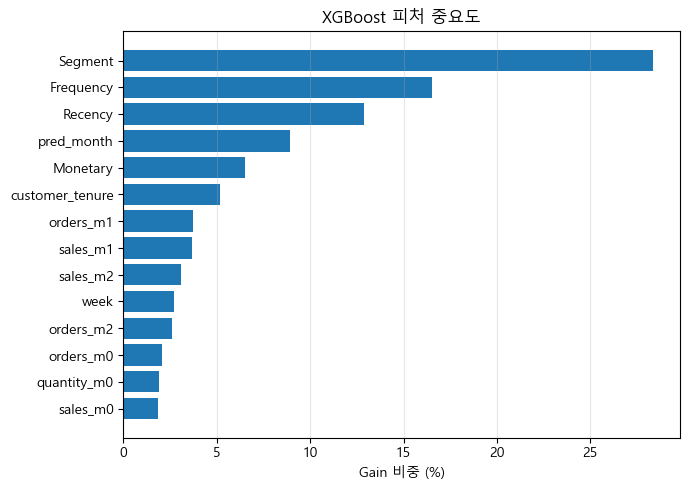

            feature  gain_pct  split
0           Segment     28.39    213
1         Frequency     16.55   1369
2           Recency     12.88   2693
3        pred_month      8.92   1948
4          Monetary      6.51   2355
5   customer_tenure      5.16   1342
6         orders_m1      3.73    323
7          sales_m1      3.68   1168
8          sales_m2      3.07   1183
9              week      2.68   1097
10        orders_m2      2.58    352
11        orders_m0      2.09    365
12      quantity_m0      1.90    935
13         sales_m0      1.86    901


In [20]:
# ============================================================
# 18. 피처 중요도 (XGB 기준)
# ============================================================
booster = xgb_model.get_booster()

# gain / weight(=split 대응)를 dict로 받아 정렬
gain_d  = booster.get_score(importance_type='total_gain')   # ← gain → total_gain
split_d = booster.get_score(importance_type='weight')

imp = (pd.DataFrame({'feature': xgb_model.feature_names_in_})
       .assign(gain  = lambda d: d['feature'].map(gain_d).fillna(0),
               split = lambda d: d['feature'].map(split_d).fillna(0).astype(int))
       .sort_values('gain', ascending=False).reset_index(drop=True))
imp['gain_pct'] = (imp['gain'] / imp['gain'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'][::-1], imp['gain_pct'][::-1])
ax.set_xlabel('Gain 비중 (%)'); ax.set_title('XGBoost 피처 중요도')
ax.grid(alpha=.3, axis='x')
plt.tight_layout(); plt.savefig(FIG_DIR / 'feature_importance.png', dpi=150); plt.show()

print(imp[['feature', 'gain_pct', 'split']])

## 9. 산출물 저장

In [21]:
# ablation 셀(30) 맨 위, 또는 cumulative 정의 근처에 추가
def customer_scores(c, truth, n_weeks=N_WEEKS):
    f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
    m = truth.merge(f4, on=['Customer ID', 'origin'], how='left', validate='one_to_one')
    assert m['F'].notna().all(), '누적확률 결측'
    return m

In [22]:
# ============================================================
# R0. 전체 그리드 복원 및 pp_all 구성
# ============================================================
def expand_full_grid(d, n_weeks=N_WEEKS):
    keys    = ['Customer ID', 'origin']
    varying = ['week', 'y']
    const   = [c for c in d.columns if c not in keys + varying]

    nun = d.groupby(keys, observed=True)[const].nunique()
    bad = nun.columns[(nun > 1).any()].tolist()
    assert not bad, f'주차별로 값이 변하는 컬럼: {bad}'

    base = d.sort_values(keys + ['week']).drop_duplicates(keys)[keys + const]
    grid = base.merge(pd.DataFrame({'week': np.arange(1, n_weeks + 1)}), how='cross')
    grid['y']    = ((grid['event'] == 1) &
                    (grid['week'] == grid['week_of_repurchase'])).astype(d['y'].dtype)
    grid['week'] = grid['week'].astype(d['week'].dtype)
    return grid[d.columns].sort_values(keys + ['week']).reset_index(drop=True)

pp_all = pd.concat([expand_full_grid(pp_train),
                    expand_full_grid(pp_val),
                    pp_test], ignore_index=True)

# --- dtype 정합: make_X의 CAT_LEVELS(=pp_train 기준)와 값 타입을 맞춘다 ---
#     pred_month가 object('10')로 새면 CAT_LEVELS(int)와 매칭 실패 → 전부 NaN 되는 사고 방지
for c in CAT:                                   # ['Segment','week','pred_month']
    pp_all[c] = pp_all[c].astype(pp_train[c].dtype)

assert not pp_all.duplicated(['Customer ID', 'origin', 'week']).any(), '키 중복'
assert (pp_all.groupby(['Customer ID', 'origin'])['week'].size() == N_WEEKS).all(), '그리드 불완전'

print(f'pp_all {pp_all.shape}')
print(sorted(pp_all['origin'].unique()))
print('pred_month dtype:', pp_all['pred_month'].dtype, '| CAT:', CAT)

pp_all (328364, 32)
['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10']
pred_month dtype: int32 | CAT: ['Segment', 'week', 'pred_month']


In [23]:
# ============================================================
# R0-c. (선택) 폴드별 Segment 재적합 — 기본 미적용
# ============================================================
# 메인 파이프라인(cust)은 저장본 Segment를 그대로 쓴다. test 폴드 == section 19 를
# 유지하려면 test 폴드도 같은 Segment여야 하므로 여기서는 '적용하지 않음'.
# fold1~3 세그먼트 누수를 더 엄격히 막고 싶으면 R2에서 폴드별로
# assign_fold_segment(slice, fit_last) 를 호출하도록 바꿀 수 있으나,
# 그 경우 test 폴드 Segment도 재적합돼 cust와 미세하게 달라질 수 있다(트레이드오프).
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

N_CLUSTERS, RANDOM_STATE, EPSILON = 4, 42, 1e-8
SEGF = ['Recency', 'Frequency', 'Monetary']

panel_rfm = pd.read_parquet(DATA_DIR / 'panel_rfm.parquet')
panel_rfm['Customer ID'] = panel_rfm['Customer ID'].astype(str)
panel_rfm['YearMonth'] = pd.PeriodIndex(panel_rfm['YearMonth'].astype(str), freq='M')  # ← 추가

SEGMENT_NAMES = ['Champions', 'New', 'Regular', 'Risk']   # CAT_LEVELS와 일치해야 함

def _derive_names(prof):
    names, rest = {}, list(prof.index)
    c = prof.loc[rest, 'Monetary'].idxmax();  names[c] = 'Champions'; rest.remove(c)
    c = prof.loc[rest, 'Recency'].idxmax();   names[c] = 'Risk';      rest.remove(c)
    c = prof.loc[rest, 'Frequency'].idxmin(); names[c] = 'New';       rest.remove(c)
    names[rest[0]] = 'Regular'
    assert set(names.values()) == set(SEGMENT_NAMES), \
        f"명명 결과 {sorted(names.values())} != {SEGMENT_NAMES}"
    return names

def segment_table(panel_rfm, fit_last, n_clusters=N_CLUSTERS, seed=RANDOM_STATE):
    mask = (panel_rfm[SEGF].notna().all(axis=1)
            & (panel_rfm['Recency'] >= 0)
            & (panel_rfm['Frequency'] > 0)
            & (panel_rfm['Monetary'] > EPSILON))
    fit_mask = mask & (panel_rfm['YearMonth'] <= pd.Period(fit_last, 'M'))

    seg_fit = np.log1p(panel_rfm.loc[fit_mask, SEGF].astype(float))
    seg_all = np.log1p(panel_rfm.loc[mask,     SEGF].astype(float))

    sc = StandardScaler().fit(seg_fit)
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(sc.transform(seg_fit))

    prof  = (panel_rfm.loc[fit_mask, SEGF]
             .assign(_c=km.predict(sc.transform(seg_fit))).groupby('_c')[SEGF].mean())
    names = _derive_names(prof)

    out = panel_rfm[['Customer ID', 'YearMonth']].copy()
    out['Segment'] = pd.Series([names[l] for l in km.predict(sc.transform(seg_all))],
                               index=panel_rfm.index[mask])
    out['origin'] = out['YearMonth'].astype(str)
    return out[['Customer ID', 'origin', 'Segment']]

def assign_fold_segment(pp, fit_last):
    seg = segment_table(panel_rfm, fit_last)
    out = pp.drop(columns='Segment').merge(seg, on=['Customer ID', 'origin'], how='left')
    return out[pp.columns]

print('정의 완료 (기본 미적용 — 저장본 Segment 사용)')

정의 완료 (기본 미적용 — 저장본 Segment 사용)


In [24]:
assert set(SEGMENT_NAMES) == set(CAT_LEVELS['Segment']), \
    f"SEGMENT_NAMES {sorted(SEGMENT_NAMES)} != CAT_LEVELS {sorted(CAT_LEVELS['Segment'])}"

In [25]:
# ============================================================
# R1. rolling-origin 설계
# ============================================================
FOLDS = [
    dict(name='fold1', train=('2010-03', '2011-06'), eval='2011-07'),
    dict(name='fold2', train=('2010-03', '2011-07'), eval='2011-08'),
    dict(name='fold3', train=('2010-03', '2011-08'), eval='2011-09'),
    dict(name='test',  train=('2010-03', '2011-09'), eval='2011-10'),
]
# 피처/인코딩은 메인(cell 3·11)의 MODEL_FEATS·CAT·NUM 을 그대로 사용한다.
# ※ 기존 주석("pred_month 제외 — 검증 origin이 미학습 범주")은 사실과 다름:
#    pred_month는 month-of-year(1~12)라 ≥12개월 학습창엔 항상 등장 → 미학습 범주 아님(포함 OK).

def slice_origins(d, lo, hi):
    return d[(d['origin'] >= lo) & (d['origin'] <= hi)].reset_index(drop=True)

for f in FOLDS:
    n = slice_origins(pp_all, *f['train'])['origin'].nunique()
    print(f"{f['name']:6s} train origin {f['train'][0]}~{f['train'][1]} ({n}개) → eval {f['eval']}")

fold1  train origin 2010-03~2011-06 (16개) → eval 2011-07
fold2  train origin 2010-03~2011-07 (17개) → eval 2011-08
fold3  train origin 2010-03~2011-08 (18개) → eval 2011-09
test   train origin 2010-03~2011-09 (19개) → eval 2011-10


In [26]:
# ============================================================
# R2. 폴드 단위 학습 · 평가  (메인 파이프라인과 동일 recipe)
# ============================================================
def run_fold(fold, pp_all, n_weeks=N_WEEKS, verbose=False):
    lo, hi, ev = fold['train'][0], fold['train'][1], fold['eval']
    sd = fold.get('seed', SEED)
    KEY = ['origin', 'Customer ID', 'week']

    pp_all = assign_fold_segment(pp_all, fit_last=hi)

     # CAT_LEVELS에 없는 라벨은 make_X의 pd.Categorical에서 무음 NaN이 됨 → 사전 차단
    # _ok = pp_all['Segment'].isna() | pp_all['Segment'].isin(CAT_LEVELS['Segment'])
    # assert _ok.all(), (f"{fold['name']}: 미등록 Segment "
    #                    f"{sorted(set(pp_all.loc[~_ok, 'Segment']))} "
    #                    f"/ CAT_LEVELS={sorted(CAT_LEVELS['Segment'])}")

    tr_all = truncate_pp(slice_origins(pp_all, lo, hi))
    inner  = sorted(tr_all['origin'].unique())[-1]
    fit    = tr_all[tr_all['origin'] <  inner].sort_values(KEY).reset_index(drop=True)   # ← 정렬
    es     = tr_all[tr_all['origin'] == inner].sort_values(KEY).reset_index(drop=True)   # ← 정렬

    ev_full = pp_all[pp_all['origin'] == ev].sort_values(KEY).reset_index(drop=True)     # ← 정렬
    ev_tr   = truncate_pp(ev_full)

    Xf, yf = make_X(fit),    fit['y'].values
    Xe, ye = make_X(es),     es['y'].values
    Xv, yv = make_X(ev_tr),  ev_tr['y'].values
    Xg     = make_X(ev_full)
    # ... 이하 B0/B1/B2/LGBM/XGB/CAT 은 전역 params·xgb_params·cat_params·make_X·to_cb 그대로 ...

    # --- B0 / B1 : 폴드 학습 구간(fit)에서 재추정 ---
    hw = fit.groupby('week')['y'].mean()
    hs = fit.groupby(['Segment', 'week'])['y'].mean()
    def p_b0(d):
        return d['week'].map(hw).values
    def p_b1(d):
        idx = pd.MultiIndex.from_arrays([d['Segment'], d['week']])
        p  = hs.reindex(idx).to_numpy()
        fb = d['week'].map(hw).to_numpy()
        return np.where(np.isnan(p), fb, p)

    # --- B2 : 메인 cell 14와 동일 구조 (NUM/CAT = MODEL_FEATS 기준) ---
    num_p = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('log', FunctionTransformer(lambda a: np.log1p(np.clip(a, 0, None)))),
                      ('sc',  StandardScaler())])
    cat_p = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    lgt = Pipeline([('prep', ColumnTransformer([('num', num_p, NUM), ('cat', cat_p, CAT)])),
                    ('clf',  LogisticRegression(max_iter=2000, C=1.0, random_state=SEED))])
    lgt.fit(fit[MODEL_FEATS].assign(**{c: fit[c].astype(str) for c in CAT}), yf)
    def p_b2(d):
        return lgt.predict_proba(d[MODEL_FEATS].assign(**{c: d[c].astype(str) for c in CAT}))[:, 1]

    # --- LGBM : 메인 cell 16과 동일 (params/valid_sets/metric 재사용) ---
    dtr = lgb.Dataset(Xf, yf, categorical_feature=CAT, free_raw_data=False)
    dva = lgb.Dataset(Xe, ye, categorical_feature=CAT, reference=dtr, free_raw_data=False)
    lm = lgb.train({**params, 'seed': sd, 'bagging_seed': sd, 'feature_fraction_seed': sd},
                   dtr, num_boost_round=3000,
                   valid_sets=[dtr, dva], valid_names=['train', 'val'],
                   callbacks=[lgb.early_stopping(150, verbose=verbose), lgb.log_evaluation(0)])
    LB = lm.best_iteration

    # --- XGB : 메인 cell 17과 동일 (xgb_params 재사용) ---
    xm = xgb.XGBClassifier(**{**xgb_params, 'random_state': sd})
    xm.fit(Xf, yf, eval_set=[(Xf, yf), (Xe, ye)], verbose=False)   # 조기종료는 마지막(val=es) 기준
    XB = xm.best_iteration

    # --- CatBoost : 메인 cell 18과 동일 (cat_params·to_cb 재사용) ---
    cm = CatBoostClassifier(**{**cat_params, 'random_seed': sd, 'verbose': False})
    cm.fit(Pool(to_cb(Xf), yf, cat_features=CAT),
           eval_set=Pool(to_cb(Xe), ye, cat_features=CAT), use_best_model=True)

    def P(d, X):
        return {'B0': p_b0(d), 'B1': p_b1(d), 'B2': p_b2(d),
                'LGBM': lm.predict(X, num_iteration=LB),
                'XGB':  xm.predict_proba(X, iteration_range=(0, XB + 1))[:, 1],
                'CAT':  cm.predict_proba(Pool(to_cb(X), cat_features=CAT))[:, 1]}
    p_tr, p_full = P(ev_tr, Xv), P(ev_full, Xg)

    truth = customer_truth(ev_full)
    rows, cust_f, cum_f = [], {}, {}
    for m in p_tr:
        pv = np.clip(p_tr[m], 1e-6, 1 - 1e-6)
        c  = cumulative(ev_full, p_full[m], n_weeks)
        cum_f[m] = c[['Customer ID', 'origin', 'week', 'h', 'S', 'F']]   # ← 추가
        f4 = c.loc[c['week'] == n_weeks, ['Customer ID', 'origin', 'F']]
        s  = truth.merge(f4, on=['Customer ID', 'origin'], validate='one_to_one')
        cust_f[m] = s
        rows.append(dict(
            fold=fold['name'], eval_origin=ev, model=m, n=len(s),
            hz_AUC=roc_auc_score(yv, pv),
            hz_PR=average_precision_score(yv, pv),
            hz_base=yv.mean(),
            hz_LogLoss=log_loss(yv, pv),
            hz_Brier=brier_score_loss(yv, pv),
            cu_AUC=roc_auc_score(s['event'], s['F']),
            cu_PR=average_precision_score(s['event'], s['F']),
            cu_LogLoss=log_loss(s['event'], np.clip(s['F'], 1e-6, 1 - 1e-6)),
            cu_Brier=brier_score_loss(s['event'], s['F']),
            실제=s['event'].mean(), 예측=s['F'].mean()))
    return pd.DataFrame(rows), cust_f, cum_f          # ← cum_f 추가

1. run_fold를 메인과 동일 recipe로 통일(피처 14열·pred_month 범주형·early-stop 동일) 
2. 행 순서 정렬로 서브샘플까지 맞춤

In [27]:
# (a) 각 폴드 경계가 eval보다 과거인가 → 전부 True 여야 클린
for f in FOLDS:
    ok = f['train'][1] < f['eval']
    print(f"{f['name']:6s} seg_fit_last={f['train'][1]} < eval {f['eval']}  →  {ok}")

# (b) fit_last=2011-08 재적합이 저장본 Segment를 재현하는가 (머신·라벨 검증)
ref08 = segment_table(panel_rfm, '2011-08')
saved = pp_all[['Customer ID', 'origin', 'Segment']].dropna().drop_duplicates()
m = saved.merge(ref08, on=['Customer ID', 'origin'], suffixes=('_saved', '_refit'))
print(f"\n2011-08 재적합 == 저장본 일치율: {(m['Segment_saved']==m['Segment_refit']).mean():.4f} (n={len(m):,})")

fold1  seg_fit_last=2011-06 < eval 2011-07  →  True
fold2  seg_fit_last=2011-07 < eval 2011-08  →  True
fold3  seg_fit_last=2011-08 < eval 2011-09  →  True
test   seg_fit_last=2011-09 < eval 2011-10  →  True

2011-08 재적합 == 저장본 일치율: 0.9075 (n=82,091)


In [28]:
# ============================================================
# R3. 전 폴드 실행 및 집계
# ============================================================
res_list, cust_by_fold, cum_by_fold = [], {}, {}
for f in FOLDS:
    print(f"\n=== {f['name']} (eval {f['eval']}) ===")
    r, cf, cmf = run_fold(f, pp_all, verbose=False)
    res_list.append(r); cust_by_fold[f['name']] = cf; cum_by_fold[f['name']] = cmf
    print(r.set_index('model')[['hz_AUC', 'hz_PR', 'cu_AUC', 'cu_PR', 'cu_Brier']].round(4))

res = pd.concat(res_list, ignore_index=True)

METRIC_COLS = ['hz_AUC', 'hz_PR', 'hz_LogLoss', 'hz_Brier',
               'cu_AUC', 'cu_PR', 'cu_LogLoss', 'cu_Brier']

cv = res[res['fold'] != 'test']
agg = (cv.groupby('model')[METRIC_COLS]
         .agg(['mean', 'std']).round(4))
print('\n=== rolling-origin 3-fold 평균±표준편차 (2011-07/08/09) ===')
print(agg)

# 논문 표용 — 주 지표만 mean ± std 한 칸으로
MAIN = ['cu_AUC', 'cu_PR', 'cu_Brier']
tidy = pd.DataFrame({
    m: (cv.groupby('model')[m].mean().round(4).astype(str)
        + ' ± ' + cv.groupby('model')[m].std().round(4).astype(str))
    for m in MAIN
})
print('\n=== 논문 표용 (검증 3-fold, mean ± std) ===')
print(tidy)

print('\n=== 최종 test (2011-10) ===')
print(res[res['fold'] == 'test'].set_index('model')
        [METRIC_COLS + ['실제', '예측']].round(4))

# PR-AUC 기준선 = 양성 비율
print('\n=== PR-AUC 무작위 기준선 (양성 비율) ===')
print('  hazard 단위:', res.groupby('fold')['hz_base'].first().round(4).to_dict())
print('  누적 단위  :', cv.groupby('fold')['실제'].first().round(4).to_dict())
print('  ※ PR-AUC는 0.5가 아니라 위 값이 무작위 수준입니다.')


=== fold1 (eval 2011-07) ===
       hz_AUC   hz_PR  cu_AUC   cu_PR  cu_Brier
model                                          
B0     0.4982  0.0411  0.5000  0.1561    0.1347
B1     0.7674  0.1171  0.7758  0.3624    0.1113
B2     0.8112  0.2278  0.8304  0.5549    0.0997
LGBM   0.8166  0.2320  0.8356  0.5590    0.1002
XGB    0.8155  0.2318  0.8341  0.5565    0.0997
CAT    0.8187  0.2383  0.8373  0.5653    0.0979

=== fold2 (eval 2011-08) ===
       hz_AUC   hz_PR  cu_AUC   cu_PR  cu_Brier
model                                          
B0     0.5010  0.0519  0.5000  0.1903    0.1544
B1     0.7288  0.1235  0.7510  0.3810    0.1311
B2     0.7781  0.2190  0.7971  0.5457    0.1206
LGBM   0.7854  0.2227  0.8038  0.5518    0.1192
XGB    0.7855  0.2224  0.8027  0.5506    0.1194
CAT    0.7833  0.2254  0.8022  0.5514    0.1244

=== fold3 (eval 2011-09) ===
       hz_AUC   hz_PR  cu_AUC   cu_PR  cu_Brier
model                                          
B0     0.5265  0.0566  0.5000  0.1948    0.156

In [29]:
# # ============================================================
# # R3-B. 시드 반복 — 모델 간 차이가 난수 변동보다 큰지 확인 (다지표)
# # ============================================================
import numpy as np, pandas as pd
from itertools import combinations
from scipy.stats import ttest_rel, wilcoxon

SEEDS = [42, 7, 2024, 1234, 99]

# (지표, 방향) — 'max' = 클수록 좋음, 'min' = 작을수록 좋음
METRICS = [
    ('hz_AUC',     'max'),
    ('hz_PR',      'max'),   # PR-AUC (average precision) — 없으면 자동 스킵
    ('hz_LogLoss', 'min'),
    ('cu_AUC',     'max'),
    ('cu_PR',      'max'),
    ('cu_LogLoss', 'min'),
    ('cu_Brier',   'min'),
]

ALPHA = 0.05

# ── 실행 ──
runs = []
for sd in SEEDS:
    for f in FOLDS:
        r, _, _ = run_fold({**f, 'seed': sd}, pp_all, verbose=False)
        r['seed'] = sd
        runs.append(r)

runs = pd.concat(runs, ignore_index=True)
cv = runs[runs['fold'] != 'test']

metrics = [(m, d) for m, d in METRICS if m in cv.columns]
skipped = [m for m, _ in METRICS if m not in cv.columns]
if skipped:
    print('[건너뜀] run_fold 결과에 없는 지표:', skipped)



def apply_holm(df, p_col, alpha=0.05):
    """
    p_col의 유효한 p-value 전체를 하나의 가설군으로 정의하여
    Holm-Bonferroni 보정을 적용한다.
    """
    out = df.copy()

    p = out[p_col].to_numpy(dtype=float)
    valid_pos = np.where(~np.isnan(p))[0]
    m = len(valid_pos)

    rank_arr = np.full(len(out), np.nan)
    critical = np.full(len(out), np.nan)
    p_adj = np.full(len(out), np.nan)
    reject = np.zeros(len(out), dtype=bool)

    if m == 0:
        out[f'{p_col}_rank'] = rank_arr
        out[f'{p_col}_critical'] = critical
        out[f'{p_col}_holm'] = p_adj
        out[f'{p_col}_sig'] = reject
        return out

    # 유효한 p-value의 오름차순 위치
    order = valid_pos[np.argsort(p[valid_pos])]

    # Holm 조정 p-value
    running_max = 0.0

    for rank, pos in enumerate(order, start=1):
        multiplier = m - rank + 1

        rank_arr[pos] = rank
        critical[pos] = alpha / multiplier

        adjusted = multiplier * p[pos]
        running_max = max(running_max, adjusted)
        p_adj[pos] = min(running_max, 1.0)

    reject[valid_pos] = p_adj[valid_pos] <= alpha

    out[f'{p_col}_rank'] = rank_arr
    out[f'{p_col}_critical'] = critical
    out[f'{p_col}_holm'] = p_adj
    out[f'{p_col}_sig'] = reject

    return out

summary_rows, all_cmp = [], []

for METRIC, DIRECTION in metrics:
    better = 'higher' if DIRECTION == 'max' else 'lower'
    print('\n' + '=' * 70)
    print(f'[{METRIC}]  ({better} is better)')
    print('=' * 70)

    # ── (1) 모델별 변동 폭 ──
    summ = (cv.groupby('model')[METRIC]
              .agg(mean='mean', std='std', min='min', max='max')
              .assign(range=lambda d: d['max'] - d['min'])
              .sort_values('mean', ascending=(DIRECTION == 'min'))
              .round(4))
    print(f'\n시드×폴드 분포 (seeds={len(SEEDS)}, folds={cv["fold"].nunique()})')
    print(summ)

    # ── (2) 순위 안정성 ──
    rank_tbl = (cv.groupby(['seed', 'fold', 'model'])[METRIC].mean()
                  .unstack('model'))
    best = rank_tbl.idxmax(axis=1) if DIRECTION == 'max' else rank_tbl.idxmin(axis=1)
    winners = best.value_counts()
    print('\n(seed, fold)별 1위 횟수')
    print(winners)

    # ── (3) 쌍대 비교 + Holm 보정 ──
    models = list(rank_tbl.columns)
    rows = []
    for a, b in combinations(models, 2):
        d = rank_tbl[[a, b]].dropna()
        diff = d[a] - d[b]
        rows.append({
            'metric': METRIC,
            'pair': f'{a} vs {b}',
            'n': len(d),
            'delta': diff.mean(),
            'sd': diff.std(),
            'p_t': ttest_rel(d[a], d[b]).pvalue,
            'p_w': wilcoxon(d[a], d[b]).pvalue if len(d) >= 6 else np.nan,
        })

    cmp_tbl = pd.DataFrame(rows)

    # 지표별로 독립적인 가설군으로 보고 보정
    # 해당 지표의 모든 모델 쌍을 하나의 가설군으로 보정
    cmp_tbl = apply_holm(cmp_tbl, 'p_t', alpha=ALPHA)
    cmp_tbl = apply_holm(cmp_tbl, 'p_w', alpha=ALPHA)

    show = cmp_tbl.copy()
    for c in ['delta', 'sd', 'p_t', 'p_t_holm', 'p_w', 'p_w_holm']:
        show[c] = show[c].astype(float).round(4)

    print('\n쌍대 비교 (paired, Holm-Bonferroni)')
    print(show[['pair', 'n', 'delta', 'sd',
                'p_t', 'p_t_holm', 'p_t_sig',
                'p_w', 'p_w_holm', 'p_w_sig']].to_string(index=False))

    n_sig = int(cmp_tbl['p_t_sig'].sum())
    print(f'→ {len(cmp_tbl)}쌍 중 Holm 보정 후 유의: {n_sig}쌍 (α={ALPHA})')

    all_cmp.append(cmp_tbl)
    summary_rows.append({
        'metric': METRIC,
        'direction': better,
        'best_mean': summ.index[0],
        'n_winners': int(winners.size),
        'top_winner': winners.index[0],
        'win_share': round(winners.iloc[0] / winners.sum(), 3),
        'n_sig_pairs': n_sig,
        'n_pairs': len(cmp_tbl),
    })

# ── 전체 요약 ──
cmp_all = pd.concat(all_cmp, ignore_index=True)
print('\n' + '=' * 70)
print('전체 요약')
print('=' * 70)
print(pd.DataFrame(summary_rows).to_string(index=False))

tot_sig = int(cmp_all['p_t_sig'].sum())
print(f'\n총 {len(cmp_all)}개 비교 중 유의: {tot_sig}개')
if tot_sig == 0:
    print('→ 어떤 지표에서도 모델 간 차이가 유의하지 않음. 순위를 주장하지 않는 것이 정확합니다.')
else:
    print('\n유의한 비교만:')
    print(cmp_all[cmp_all['p_t_sig']]
          [['metric', 'pair', 'delta', 'sd', 'p_t_holm']]
          .round(4).to_string(index=False))


[hz_AUC]  (higher is better)

시드×폴드 분포 (seeds=5, folds=3)
         mean     std     min     max   range
model                                        
LGBM   0.7840  0.0273  0.7503  0.8166  0.0663
CAT    0.7837  0.0283  0.7493  0.8187  0.0694
XGB    0.7836  0.0268  0.7487  0.8155  0.0668
B2     0.7794  0.0263  0.7489  0.8112  0.0623
B1     0.7352  0.0250  0.7093  0.7674  0.0581
B0     0.5086  0.0132  0.4982  0.5265  0.0283

(seed, fold)별 1위 횟수
CAT     7
XGB     5
LGBM    3
Name: count, dtype: int64

쌍대 비교 (paired, Holm-Bonferroni)
       pair  n   delta     sd    p_t  p_t_holm  p_t_sig    p_w  p_w_holm  p_w_sig
   B0 vs B1 15 -0.2266 0.0365 0.0000    0.0000     True 0.0006    0.0034     True
   B0 vs B2 15 -0.2708 0.0386 0.0000    0.0000     True 0.0006    0.0034     True
  B0 vs CAT 15 -0.2751 0.0404 0.0000    0.0000     True 0.0001    0.0009     True
 B0 vs LGBM 15 -0.2754 0.0397 0.0000    0.0000     True 0.0001    0.0009     True
  B0 vs XGB 15 -0.2750 0.0394 0.0000    0.0000     Tr

In [30]:
# ============================================================
# R4. 본문 지표 = rolling test 단일 소스 (hz/cust/cust_tbl 재정의)
# ============================================================
te = res[res['fold'] == 'test'].set_index('model')

hz = te[['hz_AUC', 'hz_PR', 'hz_base', 'hz_LogLoss', 'hz_Brier']].round(4)

cust = cust_by_fold['test']

cust_tbl = (te[['cu_AUC', 'cu_PR', '실제', 'cu_LogLoss', 'cu_Brier', '예측']]
            .rename(columns={'cu_AUC': 'AUC', 'cu_PR': 'PR_AUC', '실제': 'cu_base',
                             'cu_LogLoss': 'LogLoss', 'cu_Brier': 'Brier'})
            .round(4))

print('=== 주차 (test, rolling) ==='); print(hz)
print('\n=== 고객 4주 (test, rolling) ==='); print(cust_tbl)

=== 주차 (test, rolling) ===
       hz_AUC   hz_PR  hz_base  hz_LogLoss  hz_Brier
model                                               
B0     0.5269  0.0724   0.0691      0.2526    0.0645
B1     0.7090  0.1459   0.0691      0.2324    0.0615
B2     0.7548  0.2404   0.0691      0.2210    0.0588
LGBM   0.7616  0.2470   0.0691      0.2190    0.0586
XGB    0.7633  0.2484   0.0691      0.2184    0.0584
CAT    0.7530  0.2401   0.0691      0.2218    0.0588

=== 고객 4주 (test, rolling) ===
          AUC  PR_AUC  cu_base  LogLoss   Brier      예측
model                                                  
B0     0.5000  0.2474   0.2474   0.5655  0.1883  0.2018
B1     0.7259  0.4314   0.2474   0.4951  0.1610  0.2192
B2     0.7764  0.5857   0.2474   0.4583  0.1473  0.2670
LGBM   0.7839  0.5976   0.2474   0.4509  0.1448  0.2379
XGB    0.7853  0.5989   0.2474   0.4494  0.1444  0.2434
CAT    0.7754  0.5884   0.2474   0.4601  0.1472  0.2696


In [31]:
# 17. pred_month 앰블레이션 (XGB, rolling test 기준)


# test 폴드 재현
_tr  = truncate_pp(slice_origins(pp_all, '2010-03', '2011-09'))
_fit = _tr[_tr['origin'] < '2011-09']
_es  = _tr[_tr['origin'] == '2011-09']
_ev  = pp_all[pp_all['origin'] == '2011-10']
KEY  = ['origin','Customer ID','week']
_fit, _es, _ev = [d.sort_values(KEY).reset_index(drop=True) for d in (_fit,_es,_ev)]
_ev_tr = truncate_pp(_ev)

FEATS_NO_PM = [f for f in MODEL_FEATS if f != 'pred_month']     # ← MODEL_FEATS
CAT_NO_PM   = [c for c in CAT if c != 'pred_month']
def _mkX(d, feats, cats):
    X = d[feats].copy()
    for c in cats: X[c] = pd.Categorical(X[c], categories=CAT_LEVELS[c])
    for c in [f for f in feats if f not in cats]: X[c] = X[c].astype('float32')
    return X

xm_no = xgb.XGBClassifier(**xgb_params)
xm_no.fit(_mkX(_fit, FEATS_NO_PM, CAT_NO_PM), _fit['y'].values,
          eval_set=[(_mkX(_fit, FEATS_NO_PM, CAT_NO_PM), _fit['y'].values),
                    (_mkX(_es,  FEATS_NO_PM, CAT_NO_PM), _es['y'].values)], verbose=False)
XB_no = xm_no.best_iteration
p_no_tr = xm_no.predict_proba(_mkX(_ev_tr, FEATS_NO_PM, CAT_NO_PM), iteration_range=(0, XB_no+1))[:,1]
p_no_fu = xm_no.predict_proba(_mkX(_ev,    FEATS_NO_PM, CAT_NO_PM), iteration_range=(0, XB_no+1))[:,1]
s_no = customer_scores(cumulative(_ev, p_no_fu), customer_truth(_ev))

te = res[res['fold']=='test'].set_index('model')
y_ev_tr = _ev_tr['y'].values
abl = pd.DataFrame([
    dict(model='XGB (+pred_month)',
         주차AUC=te.loc['XGB','hz_AUC'], 주차LogLoss=te.loc['XGB','hz_LogLoss'],
         고객AUC=te.loc['XGB','cu_AUC'], 고객Brier=te.loc['XGB','cu_Brier'],
         예측평균=cust['XGB']['F'].mean()),
    dict(model='XGB (-pred_month)',
         주차AUC=roc_auc_score(y_ev_tr, p_no_tr),
         주차LogLoss=log_loss(y_ev_tr, np.clip(p_no_tr,1e-6,1-1e-6)),
         고객AUC=roc_auc_score(s_no['event'], s_no['F']),
         고객Brier=brier_score_loss(s_no['event'], s_no['F']),
         예측평균=s_no['F'].mean()),
]).set_index('model').round(4)
abl['실제평균'] = _ev.drop_duplicates(['Customer ID','origin'])['event'].mean().round(4)
print(abl)
print('\n→ AUC 차이 미미 + 예측평균만 이동 → pred_month는 계절 절편.')

                    주차AUC  주차LogLoss   고객AUC  고객Brier    예측평균    실제평균
model                                                                
XGB (+pred_month)  0.7633     0.2184  0.7853   0.1444  0.2434  0.2474
XGB (-pred_month)  0.7623     0.2231  0.7849   0.1496  0.1838  0.2474

→ AUC 차이 미미 + 예측평균만 이동 → pred_month는 계절 절편.


In [32]:
# ============================================================
# 20. 저장 (rolling test · XGB 단일 소스)
# ============================================================
import json

# (A) 그래프용 주차별 곡선
seg = (pp_all[pp_all['origin']=='2011-10']
       .drop_duplicates(['Customer ID','origin'])[['Customer ID','origin','Segment']])
wk  = (pp_all[pp_all['origin']=='2011-10']
       .drop_duplicates(['Customer ID','origin'])
       [['Customer ID','origin','event','week_of_repurchase']])

weekly = (cum_by_fold['test']['XGB']
          .merge(seg, on=['Customer ID','origin'])
          .merge(wk,  on=['Customer ID','origin']))
weekly.to_csv(OUT_DIR / 'weekly_curve_test.csv', index=False, encoding='utf-8-sig')
print(weekly.columns.tolist(), '| 행수:', len(weekly))

# (B) 고객 4주 누적
cust_by_fold['test']['XGB'].rename(columns={'F':'cum_prob_4w'}).to_csv(
    OUT_DIR / 'repurchase_4w_prob_test.csv', index=False, encoding='utf-8-sig')

# (C) 성능 요약
hz.to_csv(OUT_DIR / 'metrics_hazard.csv', encoding='utf-8-sig')
cust_tbl.to_csv(OUT_DIR / 'metrics_customer.csv', encoding='utf-8-sig')
abl.to_csv(OUT_DIR / 'metrics_ablation.csv', encoding='utf-8-sig')
res.to_csv(OUT_DIR / 'metrics_rolling_origin.csv', index=False, encoding='utf-8-sig')

# (D) 설정
json.dump({'model':'XGB', 'n_weeks':N_WEEKS, 'feats':MODEL_FEATS, 'cat':CAT,
           'params':{k:str(v) for k,v in xgb_params.items()}},
          open(OUT_DIR / 'model_config.json','w',encoding='utf-8'),
          ensure_ascii=False, indent=2)

print('저장 완료 →', OUT_DIR.resolve())

print('기대:', len(cum_by_fold['test']['XGB']))

['Customer ID', 'origin', 'week', 'h', 'S', 'F', 'Segment', 'event', 'week_of_repurchase'] | 행수: 22476
저장 완료 → C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model
기대: 22476


### . 유의성 검정

LSTM 수요예측에서 쓴 **Diebold-Mariano는 여기 부적합**하다. DM은 시계열 예측오차의 자기상관을 다루는 검정이고,
여기는 고객 단위 이진 분류다. 대신:

- **페어드 부트스트랩** — 고객 단위 재표집으로 $\Delta$Brier / $\Delta$LogLoss 의 신뢰구간
- 필요하면 AUC 차이는 **DeLong 검정**

고객 단위로 재표집해야 한다(주차 행 단위로 하면 같은 고객의 4행이 독립으로 취급되어 CI가 과소추정된다).

In [36]:
# ============================================================
# 19. 단측 페어드 부트스트랩 + Holm 보정  (AUC · PR · Brier)
#     H0: metric_XGB ≤ metric_comp   /   H1: metric_XGB > metric_comp
# ============================================================
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

REF   = 'XGB'
COMPS = ['B0', 'B1', 'B2', 'LGBM', 'CAT']

def _aligned(ref, comp):
    src = cust_by_fold['test']
    a = src[ref ].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    b = src[comp].sort_values(['Customer ID', 'origin']).reset_index(drop=True)
    assert (a['Customer ID'].values == b['Customer ID'].values).all(), '고객 정렬 불일치'
    return a['event'].values.astype(float), a['F'].values, b['F'].values

def one_sided_bootstrap(ref, comp, n_boot=2000, seed=SEED):
    """고객 단위 재표집. 동일 인덱스를 두 모델에 적용하는 paired 설계."""
    y, p_ref, p_cmp = _aligned(ref, comp)
    rng, n = np.random.default_rng(seed), len(y)

    d_auc, d_pr, d_bri = [], [], []
    for _ in range(n_boot):
        i  = rng.integers(0, n, n)
        yi = y[i]
        if yi.min() == yi.max():          # 한쪽 클래스만 뽑히면 AUC·PR 정의 불가
            continue
        d_auc.append(roc_auc_score(yi, p_ref[i]) - roc_auc_score(yi, p_cmp[i]))
        d_pr.append(average_precision_score(yi, p_ref[i]) - average_precision_score(yi, p_cmp[i]))
        d_bri.append(np.mean((p_cmp[i] - yi) ** 2) - np.mean((p_ref[i] - yi) ** 2))

    d_auc, d_pr, d_bri = np.array(d_auc), np.array(d_pr), np.array(d_bri)
    B = len(d_auc)

    # 단측 p = 재표집에서 개선이 나타나지 않은 비율 (+1 보정으로 p>0 보장)
    p_of = lambda d: (np.sum(d <= 0) + 1) / (B + 1)
    ci   = lambda d: f'[{np.percentile(d, 2.5):.4f}, {np.percentile(d, 97.5):.4f}]'

    auc_ref, auc_cmp = roc_auc_score(y, p_ref), roc_auc_score(y, p_cmp)
    pr_ref,  pr_cmp  = average_precision_score(y, p_ref), average_precision_score(y, p_cmp)
    bri_ref, bri_cmp = brier_score_loss(y, p_ref), brier_score_loss(y, p_cmp)

    return dict(대조군=comp,
                AUC_대조=auc_cmp, AUC_XGB=auc_ref, ΔAUC=auc_ref - auc_cmp, AUC_CI95=ci(d_auc),
                PR_대조=pr_cmp, PR_XGB=pr_ref, ΔPR=pr_ref - pr_cmp, PR_CI95=ci(d_pr),
                Brier_대조=bri_cmp, Brier_XGB=bri_ref, ΔBrier=bri_cmp - bri_ref, Brier_CI95=ci(d_bri),
                p_AUC=p_of(d_auc), p_PR=p_of(d_pr), p_Brier=p_of(d_bri))

def holm(pvals):
    """Holm-Bonferroni 순차 보정 (단조성 강제)"""
    m, order = len(pvals), np.argsort(pvals)
    adj, run = np.empty(m), 0.0
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * pvals[idx])
        adj[idx] = min(run, 1.0)
    return adj

def sig_mark(p):
    """Holm 보정 p값 기준 유의수준 표기"""
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else 'n.s.'

ht = pd.DataFrame([one_sided_bootstrap(REF, c) for c in COMPS])

# 지표별로 5개 비교의 p값을 하나의 가설군으로 보고 Holm 보정
for m in ['AUC', 'PR', 'Brier']:
    ht[f'p_Holm_{m}'] = holm(ht[f'p_{m}'].values)
    ht[f'{m}_유의']    = ht[f'p_Holm_{m}'].map(sig_mark)

n_test = len(cust_by_fold['test'][REF])
print(f'단측 페어드 부트스트랩 2,000회 | 기준 모델 {REF} | test origin 고객 {n_test:,}명')
print('H0: XGB ≤ 대조  /  H1: XGB > 대조   (지표별 Holm 보정)')
print('ΔAUC, ΔPR, ΔBrier > 0 이면 XGB 우세 (Brier는 낮을수록 좋으므로 부호 반전)')
print('유의수준: *** p<0.01   ** p<0.05   * p<0.10   n.s. 유의하지 않음')

f4 = '{:.4f}'.format
f5 = '{:.5f}'.format
for m in ['AUC', 'PR', 'Brier']:
    cols = ['대조군', f'{m}_대조', f'{m}_XGB', f'Δ{m}', f'{m}_CI95', f'p_{m}', f'p_Holm_{m}', f'{m}_유의']
    fmt  = {f'{m}_대조': f4, f'{m}_XGB': f4, f'Δ{m}': f4, f'p_{m}': f5, f'p_Holm_{m}': f5}
    print(f'\n[{m}]')
    print(ht[cols].to_string(index=False, formatters=fmt))

# 요약: 유의수준별로 유의한 비교 수 (5개 중)
summary = pd.DataFrame({
    m: {f'α={a}': int((ht[f'p_Holm_{m}'] < a).sum()) for a in (0.10, 0.05, 0.01)}
    for m in ['AUC', 'PR', 'Brier']
}).T
print(f'\n[요약] 유의한 비교 수 (총 {len(COMPS)}개 중)')
print(summary.to_string())

ht.to_csv(OUT_DIR / 'hypothesis_test_xgb.csv', index=False, encoding='utf-8-sig')

단측 페어드 부트스트랩 2,000회 | 기준 모델 XGB | test origin 고객 5,619명
H0: XGB ≤ 대조  /  H1: XGB > 대조   (지표별 Holm 보정)
ΔAUC, ΔPR, ΔBrier > 0 이면 XGB 우세 (Brier는 낮을수록 좋으므로 부호 반전)
유의수준: *** p<0.01   ** p<0.05   * p<0.10   n.s. 유의하지 않음

[AUC]
 대조군 AUC_대조 AUC_XGB   ΔAUC          AUC_CI95   p_AUC p_Holm_AUC AUC_유의
  B0 0.5000  0.7853 0.2853  [0.2714, 0.2992] 0.00050    0.00250    ***
  B1 0.7259  0.7853 0.0594  [0.0500, 0.0696] 0.00050    0.00250    ***
  B2 0.7764  0.7853 0.0089  [0.0027, 0.0156] 0.00500    0.01000    ***
LGBM 0.7839  0.7853 0.0015 [-0.0003, 0.0032] 0.05847    0.05847      *
 CAT 0.7754  0.7853 0.0100  [0.0049, 0.0153] 0.00050    0.00250    ***

[PR]
 대조군  PR_대조 PR_XGB    ΔPR           PR_CI95    p_PR p_Holm_PR PR_유의
  B0 0.2474 0.5989 0.3516  [0.3282, 0.3751] 0.00050   0.00250   ***
  B1 0.4314 0.5989 0.1676  [0.1510, 0.1833] 0.00050   0.00250   ***
  B2 0.5857 0.5989 0.0132  [0.0056, 0.0213] 0.00100   0.00300   ***
LGBM 0.5976 0.5989 0.0013 [-0.0011, 0.0039] 0.14343   0.14343  n.s.
 CAT 0.

In [ ]:
key = ['Customer ID', 'origin', 'week']
tr_all = truncate_pp(slice_origins(pp_all, '2010-03', '2011-09'))
fit    = tr_all[tr_all['origin'] < sorted(tr_all['origin'].unique())[-1]].reset_index(drop=True)

same_set   = pp_train[key].sort_values(key).reset_index(drop=True).equals(
             fit[key].sort_values(key).reset_index(drop=True))
same_order = pp_train[key].reset_index(drop=True).equals(fit[key].reset_index(drop=True))
print('행 집합 동일:', same_set, '| 행 순서 동일:', same_order)   # True, False 예상

행 집합 동일: True | 행 순서 동일: False


In [ ]:
# 저장본 Segment가 전체기간 기준인지, origin별로 다른지 체크
seg_by_origin = pp_all.groupby('origin')['Segment'].apply(
    lambda s: pp_all.loc[s.index, ['Customer ID','Segment']].drop_duplicates().shape[0])
# 같은 고객이 origin마다 Segment 바뀌는지
chk = (pp_all.drop_duplicates(['Customer ID','origin'])
       .pivot_table(index='Customer ID', columns='origin', values='Segment', aggfunc='first'))
# 한 고객의 origin별 Segment가 다 같으면 → 정적(전역) 라벨 의심
print((chk.nunique(axis=1) == 1).mean(), '비율의 고객이 전 origin 동일 Segment')
#비율이 1.0(100%)에 가까웠으면 "세그먼트가 전역 고정 라벨"이라 의심됐을 텐데, 0.129라 "각 시점 RFM으로 세그먼트 부여"가 제대로 작동

0.13597582651972984 비율의 고객이 전 origin 동일 Segment


In [ ]:
ev_tr = truncate_pp(pp_all[pp_all['origin']=='2011-10'])
print('실제 hazard(절단본):')
print(ev_tr.groupby('week')['y'].mean())

실제 hazard(절단본):
week
1    0.071187
2    0.076835
3    0.075135
4    0.050943
Name: y, dtype: float64


In [ ]:
# 예측 hazard를 절단본 기준으로 (실제와 같은 분모)
ev_tr = truncate_pp(pp_all[pp_all['origin']=='2011-10'])
pred_h_tr = (cum_by_fold['test']['XGB']
             .merge(ev_tr[['Customer ID','origin','week']], on=['Customer ID','origin','week'])
             .groupby('week')['h'].mean())
print('예측 hazard(절단본):', pred_h_tr.values)
print('실제 hazard(절단본):', ev_tr.groupby('week')['y'].mean().values)

예측 hazard(절단본): [0.06896755 0.07086271 0.06429634 0.06010529]
실제 hazard(절단본): [0.07118704 0.07683464 0.07513491 0.05094255]


In [ ]:
print([c for c in pp_all.columns if 'cohort' in c.lower() or 'first' in c.lower() or 'tenure' in c.lower()])

['customer_tenure', 'sales_per_tenure']


In [ ]:
print('test origin:', pp_test['origin'].unique())       # ['2011-10'] 한 개
print('고객 수:', pp_test['Customer ID'].nunique())      # 5619
print('한 고객당 행:', pp_test.groupby('Customer ID').size().value_counts())  # 각 4주치

test origin: ['2011-10']
고객 수: 5619
한 고객당 행: 4    5619
Name: count, dtype: int64


In [ ]:
# run_fold의 test 폴드 재현
tr_all = truncate_pp(slice_origins(pp_all, '2010-03', '2011-09'))
print('학습 origin:', sorted(tr_all['origin'].unique()))
inner = sorted(tr_all['origin'].unique())[-1]
print('조기종료 검증(inner):', inner)
print('실제 fit:', sorted(tr_all[tr_all['origin']<inner]['origin'].unique()))

학습 origin: ['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09']
조기종료 검증(inner): 2011-09
실제 fit: ['2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08']


In [ ]:
# ============================================================
# 21. 개별 고객 CRM 카드 (rolling test · XGB)
# ============================================================
ORG, PREV = '2011-10', '2011-09'
org_p = pd.Period(ORG, freq='M')

cm = cum_by_fold['test']['XGB']
a  = (pp_all[pp_all['origin'] == ORG].drop_duplicates(['Customer ID'])
      .set_index('Customer ID')
      [['Segment', 'Recency', 'Frequency', 'customer_tenure', 'event']])

H = cm.pivot_table(index='Customer ID', columns='week', values='h').sort_index(axis=1)
F = cm.pivot_table(index='Customer ID', columns='week', values='F').sort_index(axis=1)

card = pd.DataFrame(index=H.index)
card['F4'] = F[N_WEEKS]
card['resid_h'] = (H - H.mean(axis=0))[1]          # 시장 평균 대비

# (a) 코호트 — tenure는 '개월'
ten_m = a['customer_tenure'].round().astype(int)
card['cohort'] = ten_m.map(lambda m: str(org_p - m))

# (b) 지연 배수 — F회 구매 = (F-1)개 간격. 단발 고객은 세그먼트 중앙값으로
ten_d = a['customer_tenure'] * 30.44
tau_i = pd.Series(np.where(a['Frequency'] >= 2, ten_d / (a['Frequency'] - 1), np.nan),
                  index=a.index)
tau_s = tau_i.groupby(a['Segment']).transform('median')
n_int = (a['Frequency'] - 1).clip(lower=0)
k = 3
tau = (n_int * tau_i.fillna(0) + k * tau_s) / (n_int + k)
card['overdue'] = (a['Recency'] / tau).clip(upper=10)

# (c) 세그먼트 전이 — 전월 대비
prev = (pp_all[pp_all['origin'] == PREV].drop_duplicates(['Customer ID'])
        .set_index('Customer ID')['Segment'])
card['seg'], card['seg_prev'] = a['Segment'], prev.reindex(card.index)
card['transition'] = np.select(
    [card['seg_prev'].isna(), card['seg_prev'] == card['seg']],
    ['신규 유입', card['seg'].astype(str) + ' (유지)'],
    default=card['seg'].astype(str) + ' ← ' + card['seg_prev'].astype(str))

# (d) 설득 가능성 — 확실한 재구매자/확실한 이탈자 양끝을 죽임
card['persuadable'] = 4 * card['F4'] * (1 - card['F4'])

print('코호트 분포:'); print(card['cohort'].value_counts().sort_index().to_string())
print('\n지연 배수:', card['overdue'].describe()[['25%','50%','75%']].round(2).to_dict())

# (e) 대표 3인 — 서로 다른 상황을 보여주는 축으로 선정
sel = {
    '이탈 임박':   card[(card['overdue'] > 1.5) & (card['F4'].between(.15, .45))]
                       .nlargest(1, 'persuadable'),
    '유지 중':     card[(card['overdue'] < 0.8) & (card['seg'] == 'Champions')]
                       .nlargest(1, 'F4'),
    '개입 보류':   card[(card['F4'] < .08) & (card['overdue'] > 3)]
                       .nsmallest(1, 'F4'),
}
reps = pd.concat(sel.values())
reps['상황'] = list(sel.keys())

out = pd.DataFrame({
    '상황':          reps['상황'],
    '최초구매 코호트': reps['cohort'],
    '세그먼트':      reps['transition'],
    'F̂(4주)':        reps['F4'].round(3),
    '지연 배수':     reps['overdue'].round(2).map('{:.2f}×'.format),
    '잔차 hazard':   reps['resid_h'].round(3),
    '설득 가능성':   reps['persuadable'].round(3),
}).T
out.columns = [f'고객 {c}' for c in list('ABC')[:out.shape[1]]]
print('\n' + out.to_string())
out.to_csv(OUT_DIR / 'crm_customer_cards.csv', encoding='utf-8-sig')

코호트 분포:
cohort
2009-12    949
2010-01    368
2010-02    375
2010-03    441
2010-04    294
2010-05    254
2010-06    267
2010-07    185
2010-08    163
2010-09    237
2010-10    372
2010-11    324
2010-12     76
2011-01     72
2011-02    125
2011-03    179
2011-04    106
2011-05    111
2011-06    108
2011-07    101
2011-08    107
2011-09    186
2011-10    219

지연 배수: {'25%': 0.31, '50%': 0.76, '75%': 1.27}

                     고객 A            고객 B       고객 C
상황                  이탈 임박            유지 중      개입 보류
최초구매 코호트          2009-12         2009-12    2010-01
세그먼트       Champions (유지)  Champions (유지)  Risk (유지)
F̂(4주)              0.449           0.998      0.055
지연 배수               3.12×           0.65×      3.41×
잔차 hazard            0.07           0.758     -0.055
설득 가능성               0.99           0.008      0.208


In [ ]:
cm = cum_by_fold['test']['XGB']
H = cm.pivot_table(index='Customer ID', columns='week', values='h').sort_index(axis=1)
w = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
     .set_index('Customer ID')[['event','week_of_repurchase']])
ev = w[w['event']==1]
print(H.loc[ev.index].groupby(ev['week_of_repurchase']).mean().round(4))

week                     1       2       3       4
week_of_repurchase                                
1.0                 0.1661  0.1855  0.1877  0.1811
2.0                 0.1335  0.1539  0.1555  0.1512
3.0                 0.1018  0.1229  0.1254  0.1227
4.0                 0.0934  0.1094  0.1107  0.1094


In [ ]:
cm = cum_by_fold['test']['XGB']
H  = cm.pivot_table(index='Customer ID', columns='week', values='h').sort_index(axis=1)
Hn = H.div(H.sum(axis=1), axis=0)

seg = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
       .set_index('Customer ID')['Segment'])
Hn['seg'], Hn['tilt'] = seg, Hn[4] - Hn[1]      # 양수=후진, 음수=전진

print(Hn.groupby('seg')['tilt'].describe(percentiles=[.05,.5,.95]).round(3))

            count   mean    std    min     5%    50%    95%    max
seg                                                               
Champions  1033.0  0.049  0.042 -0.057 -0.012  0.043  0.126  0.153
New        1062.0  0.046  0.033 -0.013  0.004  0.041  0.107  0.157
Regular    1478.0  0.025  0.014 -0.026  0.003  0.025  0.046  0.065
Risk       2046.0  0.014  0.014 -0.017 -0.006  0.009  0.040  0.046


In [ ]:
aov = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
       .set_index('Customer ID')['avg_order_value'])
card['aov'] = aov
if 'event' not in card.columns:
    card['event'] = (pp_all[pp_all['origin']=='2011-10']
                     .drop_duplicates('Customer ID').set_index('Customer ID')['event'])

# ── 십분위 (1 = 상위 10%) ─────────────────────────────
def decile(s):
    return pd.qcut(s.rank(method='first', ascending=False), 10,
                   labels=range(1, 11)).astype(int)

card['dec_all'] = decile(card['F4'])                            # 전체 기준
card['dec_seg'] = card.groupby('seg')['F4'].transform(decile)   # 세그먼트 내

print('세그먼트 × 전체십분위 분포')
print(pd.crosstab(card['seg'], card['dec_all']).to_string(), '\n')

# ── 전략 정의: 세그먼트 내 십분위 ────────────────────
D = 'dec_seg'
RULES = {
    '①': card['seg'].eq('Champions') & card[D].le(3),                    # 상위 30%
    '②': card['seg'].eq('Regular')   & card[D].ge(6) & card['cohort'].lt('2010-11'),
    '③': card['seg'].eq('New')       & card[D].le(3),
    '④': card['seg'].eq('Risk')      & (card[D].le(3) | card['cohort'].eq('2010-11')),
}
SEG = {'①':'Champions', '②':'Regular', '③':'New', '④':'Risk'}

# ── 요약 ─────────────────────────────────────────────
base, tot_ev = card['event'].mean(), card['event'].sum()
rows = []
for k, m in RULES.items():
    g = card[m]
    rows.append({'전략': k, '세그먼트': SEG[k],
                 '대상수': int(m.sum()), '비율': f'{m.mean()*100:.1f}%',
                 'F̂평균': round(g['F4'].mean(), 3),
                 '실제재구매율': round(g['event'].mean(), 3),
                 '포착률': f'{g["event"].sum()/tot_ev*100:.1f}%',
                 '리프트': round(g['event'].mean()/base, 2),
                 'AOV중앙': round(g['aov'].median(), 1)})

print(pd.DataFrame(rows).to_string(index=False))
print(f'\n전체 기준 재구매율 {base:.3f} | 재구매자 {int(tot_ev)}명')
print('중복 배정:', int((sum(RULES.values()) > 1).sum()), '명')
print('미배정   :', int((sum(RULES.values()) == 0).sum()), '명')

세그먼트 × 전체십분위 분포
dec_all     1    2    3    4    5    6    7    8    9    10
seg                                                        
Champions  512  323  126   50   10    1    6    2    3    0
New         43   84  164  289  240  127   86   29    0    0
Regular      7  155  272  209  191  218  139  107  180    0
Risk         0    0    0   14  121  215  331  424  379  562 

전략      세그먼트  대상수    비율  F̂평균  실제재구매율   포착률  리프트  AOV중앙
 ① Champions  310  5.5% 0.786   0.835 18.6% 3.38  370.0
 ②   Regular  708 12.6% 0.137   0.131  6.7% 0.53  296.6
 ③       New  319  5.7% 0.369   0.429  9.9% 1.74  297.5
 ④      Risk  680 12.1% 0.164   0.162  7.9% 0.65  213.0

전체 기준 재구매율 0.247 | 재구매자 1390명
중복 배정: 0 명
미배정   : 3602 명


In [ ]:
ch = card['seg'].eq('Champions')
cols = ['Frequency', 'Monetary', 'avg_order_value', 'avg_purchase_qty']
a = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
     .set_index('Customer ID'))

print(a.loc[card.index[ch], cols].describe(percentiles=[.5,.9,.95,.99]).round(1))

       Frequency  Monetary  avg_order_value  avg_purchase_qty
count     1033.0    1033.0           1033.0            1033.0
mean        19.1   10314.5            480.0             298.0
std         23.0   29404.9            471.0             378.6
min          5.0    1106.6             29.0              14.8
50%         13.0    5005.7            364.6             219.5
90%         33.0   16156.4            797.8             480.9
95%         45.4   25877.5           1071.7             721.5
99%        127.8  102008.3           2341.2            1867.7
max        330.0  551592.0           6846.3            6081.9


In [ ]:
aov = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
       .set_index('Customer ID')['avg_order_value'])
qty = (pp_all[pp_all['origin']=='2011-10'].drop_duplicates('Customer ID')
       .set_index('Customer ID')['avg_purchase_qty'])
card['aov'] = aov
card['qty'] = qty
if 'event' not in card.columns:
    card['event'] = (pp_all[pp_all['origin']=='2011-10']
                     .drop_duplicates('Customer ID').set_index('Customer ID')['event'])

# ── 십분위 (1 = 상위 10%) ─────────────────────────────
def decile(s):
    return pd.qcut(s.rank(method='first', ascending=False), 10,
                   labels=range(1, 11)).astype(int)

card['dec_all'] = decile(card['F4'])
card['dec_seg'] = card.groupby('seg')['F4'].transform(decile)

QTY_MED = card['qty'].median()          # 전체 Qty 중앙값
print(f'전체 Qty 중앙값: {QTY_MED:.1f}\n')
print('세그먼트 × 전체십분위 분포')
print(pd.crosstab(card['seg'], card['dec_all']).to_string(), '\n')

# ── 전략 정의 ────────────────────────────────────────

RULES = {
    '①': card['seg'].eq('Champions') & card['dec_all'].le(4)
         & card['cohort'].le('2010-11') & card['qty'].le(QTY_MED),
    '②': card['seg'].eq('Regular')   & card['dec_seg'].ge(6) & card['cohort'].le('2010-11'),
    '③': card['seg'].eq('New')       & card['dec_all'].le(4) & card['cohort'].ge('2011-08'),
    '④': card['seg'].eq('Risk')      & (card['dec_seg'].le(3) | card['cohort'].eq('2010-11')),
}
SEG = {'①':'Champions', '②':'Regular', '③':'New', '④':'Risk'}

# ── 요약 ─────────────────────────────────────────────
base, tot_ev = card['event'].mean(), card['event'].sum()
rows = []
for k, m in RULES.items():
    g = card[m]
    rows.append({'전략': k, '세그먼트': SEG[k],
                 '대상수': int(m.sum()), '비율': f'{m.mean()*100:.1f}%',
                 'F̂평균': round(g['F4'].mean(), 3),
                 '실제재구매율': round(g['event'].mean(), 3),
                 '포착률': f'{g["event"].sum()/tot_ev*100:.1f}%',
                 '리프트': round(g['event'].mean()/base, 2),
                 'AOV평균': round(g['aov'].mean(), 1),
                 'AOV중앙': round(g['aov'].median(), 1)})

print(pd.DataFrame(rows).to_string(index=False))
print(f'\n전체 기준 재구매율 {base:.3f} | 재구매자 {int(tot_ev)}명')
print('중복 배정:', int((sum(RULES.values()) > 1).sum()), '명')
print('미배정   :', int((sum(RULES.values()) == 0).sum()), '명')

전체 Qty 중앙값: 154.5

세그먼트 × 전체십분위 분포
dec_all     1    2    3    4    5    6    7    8    9    10
seg                                                        
Champions  512  323  126   50   10    1    6    2    3    0
New         43   84  164  289  240  127   86   29    0    0
Regular      7  155  272  209  191  218  139  107  180    0
Risk         0    0    0   14  121  215  331  424  379  562 

전략      세그먼트  대상수    비율  F̂평균  실제재구매율   포착률  리프트  AOV평균  AOV중앙
 ① Champions  289  5.1% 0.536   0.567 11.8% 2.29  243.0  226.2
 ②   Regular  729 13.0% 0.138   0.132  6.9% 0.53  477.5  296.7
 ③       New  249  4.4% 0.313   0.357  6.4% 1.44  488.4  401.1
 ④      Risk  680 12.1% 0.164   0.162  7.9% 0.65  276.9  213.0

전체 기준 재구매율 0.247 | 재구매자 1390명
중복 배정: 0 명
미배정   : 3672 명


In [ ]:
# 1) 결측 규모 — 단월 기준이면 크게 나옴
print(card['aov'].isna().sum(), '/', len(card))

# 2) origin별로 값이 변하는지 — 누적/단월이면 변하고, 고정값이면 안 변함
chk = (pp_all[pp_all['Customer ID'] == card.index[0]]
       .drop_duplicates('origin')[['origin', 'avg_order_value']])
print(chk)

0 / 5619
         origin  avg_order_value
0       2010-03            27.05
4       2010-04            27.05
8       2010-05            27.05
12      2010-06            84.68
16      2010-07            84.68
20      2010-08            84.68
24      2010-09            84.68
28      2010-10            84.68
32      2010-11            84.68
36      2010-12            84.68
40      2011-01            56.45
44      2011-02            56.45
48      2011-03            56.45
52      2011-04            56.45
56      2011-05            56.45
60      2011-06            56.45
64      2011-07            56.45
68      2011-08            56.45
284284  2011-09            56.45
305888  2011-10            56.45
